In [1]:
library(BiocManager)
library(DOSE)
library(readxl)
library(clusterProfiler)
library(org.Mm.eg.db)
require(DOSE)
library(writexl)
library(pheatmap)
library(openxlsx)
library(readr)
library(tximportData)

library(ggplot2)
library(dplyr)
library(gridExtra)
library(cowplot)

library(dplyr)
library(ggpubr)
library(ggrepel)
library(stringr)
library(GenomicFeatures)
library(ape)
library(tibble)
library(tximport)
library(ggplot2)
library(DESeq2)
library(tsne)
library(pheatmap)

Bioconductor version '3.18' is out-of-date; the current release version '3.22'
  is available with R version '4.5'; see https://bioconductor.org/install



DOSE v3.28.2  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use DOSE in published research, please cite:
Guangchuang Yu, Li-Gen Wang, Guang-Rong Yan, Qing-Yu He. DOSE: an R/Bioconductor package for Disease Ontology Semantic and Enrichment analysis. Bioinformatics 2015, 31(4):608-609


clusterProfiler v4.10.1  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading requi

In [ ]:
library(GenomicRanges)
library(rtracklayer)
library(JASPAR2020)
library(motifmatchr)
library(TFBSTools)
library(stringr)
library(BSgenome.Mmusculus.UCSC.mm10)

In [3]:
create_motif_counts_df <- function(granges_obj, region_names, genome, object_db) {
  
  # Obtener los matches como posiciones (una lista de GRanges, uno por motif)
  motif_matches <- motifmatchr::matchMotifs(
    pwms = object_db,
    subject = granges_obj,
    genome = genome,
    out = "positions"
  )
  
  results_list <- vector("list", length(granges_obj) * length(object_db))
  k <- 1
  
  for (i in seq_along(object_db)) {
    if (i %%100 == 0){
        print(i)
        flush.console()
    }
    motif <- object_db[[i]]@name
    matches_gr <- motif_matches[[i]]  # GRanges con todos los hits para ese motif
    
    # Contar cuántos overlaps hay con cada región
    counts <- GenomicRanges::countOverlaps(granges_obj, matches_gr)
    
    for (j in seq_along(granges_obj)) {
      results_list[[k]] <- list(
        region = region_names[j],
        motif_id = object_db[[i]]@ID,
        motif_tf = motif,
        count = counts[j]
      )
      k <- k + 1
    }
  }
  
  result_df <- do.call(rbind, lapply(results_list, as.data.frame))
  return(result_df)
}


In [4]:
# Function to perform the t-test and extract results for each TF
perform_wilcox_test <- function(tf, data) {

  # Extract data for this TF
  lt_data <- data %>% filter(motif_tf == tf, type == 'long-term')
  st_data <- data %>% filter(motif_tf == tf, type == 'short-term')
  
  # Extract counts
  lt_counts <- lt_data %>% pull(count)
  st_counts <- st_data %>% pull(count)
  
  # Handle cases where there are not enough data
  if(length(lt_counts) == 0 || length(st_counts) == 0) {
    return(data.frame(
      motif_tf = tf,
      motif_id =  data %>% filter(motif_tf == tf) %>% pull(motif_id) %>% head(1),
      n_lt_mem = sum(lt_counts >= 1),
      n_st_mem = sum(st_counts >= 1),
      mean_lt = ifelse(length(lt_counts) > 0, mean(lt_counts), NA),
      mean_st = ifelse(length(st_counts) > 0, mean(st_counts), NA),
      t_stat = NA,
      p_value = NA
    ))
  }
  
  # Calculate number of memory regions with at least 1 motif
  n_lt <- sum(lt_counts >= 1)
  n_st <- sum(st_counts >= 1)
  
  # Calculate means
  mean_lt <- mean(lt_counts)
  mean_st <- mean(st_counts)
    
  wilcox.result <- wilcox.test(lt_counts, st_counts)
  
  # Create results dataframe
  data.frame(
    motif_tf = tf,
    motif_id =  data %>% filter(motif_tf == tf) %>% pull(motif_id) %>% head(1),
    n_lt_mem = n_lt,
    n_st_mem = n_st,
    mean_lt = mean_lt,
    mean_st = mean_st,
    p_value = wilcox.result$p.value
  )
}


## Read files

In [6]:
short_term_granges <- import("D30_memory_M12_resolved.bed", format = "BED")
long_term_granges <- import("D30_M12_memory.bed", format = "BED")

mcols(short_term_granges)$type <- "short-term"
mcols(long_term_granges)$type <- "long-term"


In [7]:
short_region_names <- paste0(
  seqnames(short_term_granges), ":", 
  start(short_term_granges), "-", 
  end(short_term_granges)
)

long_region_names <- paste0(
  seqnames(long_term_granges), ":", 
  start(long_term_granges), "-", 
  end(long_term_granges)
)

## Jaspar database

In [8]:
jaspar_opts <- list(collection = "CORE", 
                    tax_group = "vertebrates", 
                    all_versions = FALSE)
jaspar_db <- getMatrixSet(JASPAR2020, jaspar_opts)

In [9]:
short_term_counts <- create_motif_counts_df(
  short_term_granges,
  short_region_names,
  BSgenome.Mmusculus.UCSC.mm10,
  jaspar_db
)
short_term_counts$type = 'short-term'

[1] 100
[1] 200
[1] 300
[1] 400
[1] 500
[1] 600
[1] 700


In [10]:
long_term_counts <- create_motif_counts_df(
  long_term_granges,
  long_region_names,
  BSgenome.Mmusculus.UCSC.mm10,
  jaspar_db
)
long_term_counts$type = 'long-term'

[1] 100
[1] 200
[1] 300
[1] 400
[1] 500
[1] 600
[1] 700


In [11]:
length(jaspar_db)

[1] 746

In [12]:
merged_df <- rbind(short_term_counts, long_term_counts)

In [13]:
tfs <- unique(merged_df$motif_tf)

results_list <- lapply(tfs, perform_wilcox_test, data = merged_df)

final_results <- bind_rows(results_list)

final_results <- final_results %>% 
  arrange(p_value) %>%
  mutate(significant = p_value < 0.05)

final_results$q_value <- p.adjust(final_results$p_value, method = 'BH')

## Memory vs resolved

In [14]:
memory_granges <- import("D30_memory.bed", format = "BED")
resolved_granges <- import("D6_induced_D30_resolved.bed", format = "BED")

mcols(memory_granges)$type <- "memory"
mcols(resolved_granges)$type <- "resolved"


In [15]:
memory_names <- paste0(
  seqnames(memory_granges), ":", 
  start(memory_granges), "-", 
  end(memory_granges)
)

resolved_names <- paste0(
  seqnames(resolved_granges), ":", 
  start(resolved_granges), "-", 
  end(resolved_granges)
)

In [16]:
memory_counts <- create_motif_counts_df(
  memory_granges,
  memory_names,
  BSgenome.Mmusculus.UCSC.mm10,
  jaspar_db
)
memory_counts$type = 'memory'

[1] 100
[1] 200
[1] 300
[1] 400
[1] 500
[1] 600
[1] 700


In [17]:
resolved_counts <- create_motif_counts_df(
  resolved_granges,
  resolved_names,
  BSgenome.Mmusculus.UCSC.mm10,
  jaspar_db
)
resolved_counts$type = 'resolved'

[1] 100
[1] 200
[1] 300
[1] 400
[1] 500
[1] 600
[1] 700


In [18]:
merged_df <- rbind(memory_counts, resolved_counts)

In [19]:
# Function to perform the Wilcoxon test and extract results for each TF
perform_wilcox_test2 <- function(tf, data) {

  # Extract data for this TF
  lt_data <- data %>% filter(motif_tf == tf, type == 'memory')
  st_data <- data %>% filter(motif_tf == tf, type == 'resolved')
  
  # Extract counts
  lt_counts <- lt_data %>% pull(count)
  st_counts <- st_data %>% pull(count)
  
  # Handle cases where there are not enough data
  if(length(lt_counts) == 0 || length(st_counts) == 0) {
    return(data.frame(
      motif_tf = tf,
      motif_id =  data %>% filter(motif_tf == tf) %>% pull(motif_id) %>% head(1),
      n_lt_mem = sum(lt_counts >= 1),
      n_st_mem = sum(st_counts >= 1),
      mean_lt = ifelse(length(lt_counts) > 0, mean(lt_counts), NA),
      mean_st = ifelse(length(st_counts) > 0, mean(st_counts), NA),
      t_stat = NA,
      p_value = NA
    ))
  }
  
  # Calculate number of memory regions with at least 1 motif
  n_lt <- sum(lt_counts >= 1)
  n_st <- sum(st_counts >= 1)
  
  # Calculate means
  mean_lt <- mean(lt_counts)
  mean_st <- mean(st_counts)

  wilcox.result <- wilcox.test(lt_counts, st_counts)
  
  # Create results dataframe
  data.frame(
    motif_tf = tf,
    motif_id =  data %>% filter(motif_tf == tf) %>% pull(motif_id) %>% head(1),
    n_lt_mem = n_lt,
    n_st_mem = n_st,
    mean_lt = mean_lt,
    mean_st = mean_st,
    p_value = wilcox.result$p.value
  )
}


In [21]:
tfs <- unique(merged_df$motif_tf)

results_list <- lapply(tfs, perform_wilcox_test2, data = merged_df)

final_results2 <- bind_rows(results_list)

final_results2 <- final_results2 %>% 
  arrange(p_value) %>%
  mutate(significant = p_value < 0.05)

final_results2$q_value <- p.adjust(final_results2$p_value, method = 'BH')

## Store data

In [22]:
write.csv(final_results, 'JASPAR_lt_vs_st.csv', row.names = FALSE)

In [23]:
write.csv(final_results2, 'JASPAR_mem_vs_resolved.csv', row.names = FALSE)

## Read Data

In [24]:
final_results = read.csv('JASPAR_lt_vs_st.csv') # Long-term vs Short-term
final_results2 = read.csv('JASPAR_mem_vs_resolved.csv') # Memory vs resolved

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


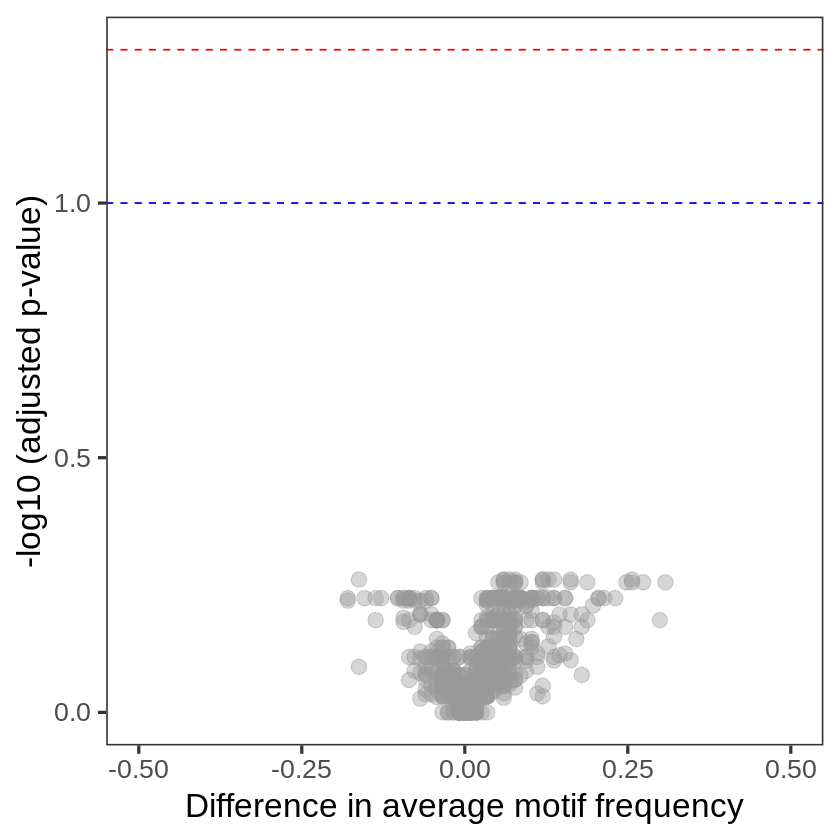

In [25]:
p1 <- ggplot(final_results %>% arrange(p_value),
       aes(x = mean_lt - mean_st, y = -log10(q_value))) +
 geom_point(size = 4, shape = 21, alpha = 0.4, fill = 'grey60', color = 'grey60') +
  geom_hline(yintercept = -log10(0.1), linetype = "dashed", color = "blue") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "red") +
  xlab("Difference in average motif frequency") +
  ylab("-log10 (adjusted p-value)") +
  theme_bw(base_size = 20) +
  theme(legend.position = 'none',
        panel.grid.minor = element_blank(),
       panel.grid.major = element_blank()) + 
  scale_x_continuous(limits = c(-0.5, 0.5))
p1

In [26]:
final_results2 = final_results2 %>% mutate(TFtype = ifelse(str_detect(motif_tf, 'FOS'), 'FOS',
                                         ifelse(str_detect(motif_tf, 'STAT'), 'STAT',
                                               ifelse(str_detect(motif_tf, 'ETS'), 'ETS', 'Others'))))
final_results2$TFtype = factor(final_results2$TFtype, levels = c('FOS', 'STAT', 'ETS', 'Others'))

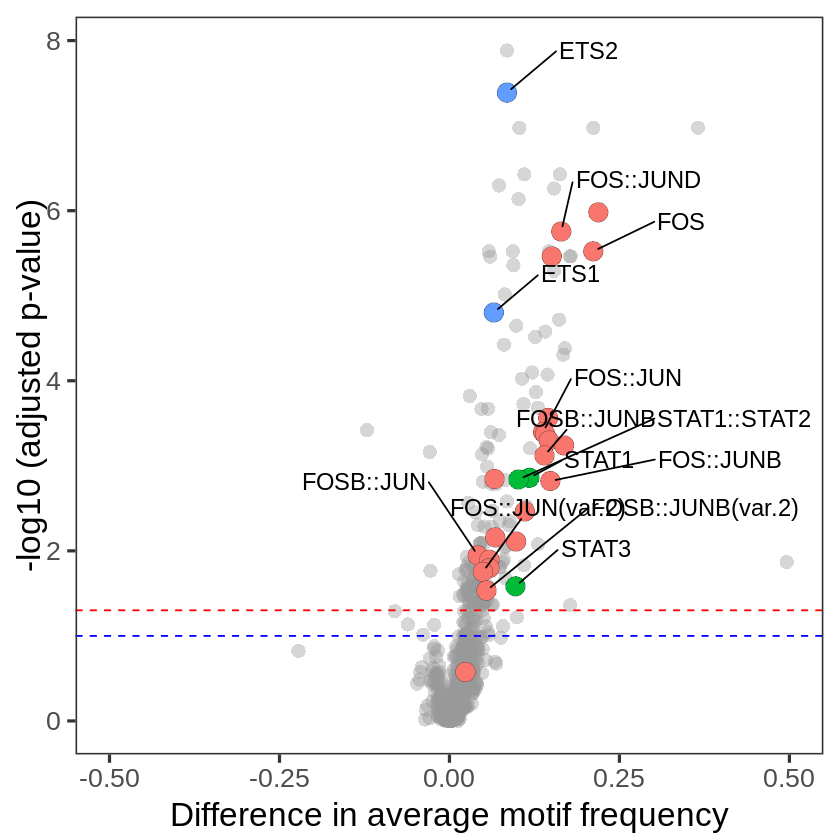

In [27]:
p2 <- ggplot() +
  geom_point(data = final_results2 %>% filter(TFtype == 'Others'),
             mapping = aes(x = mean_lt - mean_st, y = -log10(q_value)), fill = 'grey60', color = 'grey60', alpha = 0.4, shape = 21, size = 4, stroke = 0) +
  geom_point(data = final_results2 %>% filter(TFtype != 'Others'),
             mapping = aes(x = mean_lt - mean_st, y = -log10(q_value), fill = TFtype), color = 'black', shape = 21, size = 5.5, stroke = 0.1) +
  geom_text_repel(data = final_results2 %>% filter(TFtype != 'Others', !str_detect(motif_tf, 'FOSL')),
                  mapping = aes(x = mean_lt - mean_st, y = -log10(q_value), label = motif_tf),
                  size = 5, max.overlaps = 30,
                  nudge_y = 0.5,
                  nudge_x = 0.12,
                  point.padding = 0.3,
                  box.padding = 0.5) + 
  geom_hline(yintercept = -log10(0.1), linetype = "dashed", color = "blue") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "red") +
  xlab("Difference in average motif frequency") +
  ylab("-log10 (adjusted p-value)") +
  theme_bw(base_size = 20) +
  theme(legend.position = 'none',
        panel.grid.minor = element_blank(),
       panel.grid.major = element_blank()) + 
  scale_x_continuous(limits = c(-0.5, 0.5))

p2

In [203]:
ggsave("JASPAR2020_motifmatchR_volcano_memory_vs_resolved.pdf", plot = p2, width = 4.5, height = 6)

In [204]:
ggsave("JASPAR2020_motifmatchR_volcano_ltmem_vs_stmem.pdf", plot = p1, width = 4.5, height = 6)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
